# Train CNN Baseline

This notebook trains the `CNNBaseline` model from `model_classes/cnn_baseline.py` using the `RGBImageDataset` (in `data_loaders/rgb_data_loader.py`).

It follows the same simple training loop style as `train_mlp_baseline.ipynb` but uses image crops as input.

In [33]:
import os
import sys
# Ensure project root is on sys.path
PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
# Project root ensured on sys.path

In [34]:
# Imports and utilities
from typing import Dict, Any
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T

from model_classes.cnn_baseline import create_cnn_baseline
from data_loaders.rgb_data_loader import RGBImageDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [35]:
# Create datasets and dataloaders (images)
torch.manual_seed(42)
# Use a small image size so the default CNN remains small
image_size = 64
# Compose basic transforms: Resize -> (optional) center crop -> leave as PIL so dataset will convert to tensor
transform = T.Compose([T.Resize((image_size, image_size))])

crops_root = os.path.join(PROJECT_ROOT, 'data', 'crops')
train_ds = RGBImageDataset(crops_root=crops_root, split='train', transform=transform)
val_ds = RGBImageDataset(crops_root=crops_root, split='val', transform=transform)

# Infer channels and classes from a sample
sample = train_ds[0]['image']
if isinstance(sample, torch.Tensor):
    input_channels = int(sample.size(0))
else:
    # fallback
    input_channels = 3
num_classes = train_ds.num_classes

print('Dataset sizes: train=', len(train_ds), 'val=', len(val_ds))
print('Input channels:', input_channels, 'Num classes:', num_classes)

# DataLoaders
batch_size = 64
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)
# quick smoke
batch = next(iter(train_loader))
if isinstance(batch, dict):
    xb = batch['image']
    yb = batch['label']
else:
    xb, yb = batch
print(f'Batch shapes: {getattr(xb, "shape", None)} {getattr(yb, "shape", None)}')

Dataset sizes: train= 413429 val= 54001
Input channels: 3 Num classes: 18
Batch shapes: torch.Size([64, 3, 64, 64]) torch.Size([64])


In [36]:
# Training and evaluation helpers (image input)
def train_epoch(model: nn.Module, loader: DataLoader, optimizer, criterion, log_interval: int = 0) -> Dict[str, float]:
    model.train()
    total_loss = 0.0
    total_correct = 0
    total = 0
    for batch in loader:
        if isinstance(batch, dict):
            xb = batch['image']
            yb = batch['label']
        else:
            xb, yb = batch
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        bsz = xb.size(0)
        total_loss += loss.item() * bsz
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total += bsz
    return {'loss': total_loss / total, 'acc': total_correct / total}

def evaluate(model: nn.Module, loader: DataLoader, criterion) -> Dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, dict):
                xb = batch['image']
                yb = batch['label']
            else:
                xb, yb = batch
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            total_correct += (preds == yb).sum().item()
            total += xb.size(0)
    return {'loss': total_loss / total, 'acc': total_correct / total}

In [37]:
# Fixed hyperparameter training (single configuration)
final_models_dir = os.path.join(PROJECT_ROOT, 'final_models')
os.makedirs(final_models_dir, exist_ok=True)
# hyperparams
lr = 1e-3
conv_channels = (32, 64)
kernel_size = 3
pool_every = 2
dropout = 0.1
activation = 'relu'
batchnorm = False
batch_size = 64
max_epochs = 8
criterion = nn.CrossEntropyLoss()

# build model and loaders (recreate train/val loaders with desired batch_size)
model = create_cnn_baseline(input_channels=input_channels, num_classes=num_classes, conv_channels=conv_channels, kernel_size=kernel_size, pool_every=pool_every, dropout=dropout, activation=activation, batchnorm=batchnorm)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

best_val_acc = 0.0
best_state = None
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(1, max_epochs + 1):
    tr = train_epoch(model, train_loader, optimizer, criterion)
    va = evaluate(model, val_loader, criterion)
    history['train_loss'].append(tr['loss'])
    history['train_acc'].append(tr['acc'])
    history['val_loss'].append(va['loss'])
    history['val_acc'].append(va['acc'])
    print(f'Epoch {epoch}/{max_epochs} | train_loss={tr["loss"]:.4f} train_acc={tr["acc"]:.4f} | val_loss={va["loss"]:.4f} val_acc={va["acc"]:.4f}')
    if va['acc'] > best_val_acc:
        best_val_acc = va['acc']
        best_state = {'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(), 'epoch': epoch}

# persist best
out_path = os.path.join(final_models_dir, 'cnn_baseline.pth')
if best_state is not None:
    torch.save({'config': {'lr': lr, 'conv_channels': conv_channels, 'dropout': dropout, 'batchnorm': batchnorm, 'batch_size': batch_size, 'max_epochs': max_epochs}, 'best_val_acc': best_val_acc, 'state': best_state}, out_path)
    # Also write/update a combined metadata JSON file so models can be recreated later
    meta_entry = {
        'model_type': 'cnn_baseline',
        'data_type': 'rgb',
        'input_channels': input_channels,
        'num_classes': num_classes,
        'conv_channels': list(conv_channels),
        'kernel_size': kernel_size,
        'pool_every': pool_every,
        'dropout': dropout,
        'activation': activation,
        'batchnorm': batchnorm,
        'image_size': image_size,
        'training': {'lr': lr, 'batch_size': batch_size, 'max_epochs': max_epochs},
        'best_val_acc': best_val_acc,
        'checkpoint_path': out_path
    }
    combined_meta_path = os.path.join(final_models_dir, 'models_metadata.json')
    try:
        import json
        combined = {}
        if os.path.exists(combined_meta_path):
            with open(combined_meta_path, 'r') as cf:
                try:
                    combined = json.load(cf)
                except Exception:
                    combined = {}
        combined['cnn_baseline'] = meta_entry
        with open(combined_meta_path, 'w') as cf:
            json.dump(combined, cf, indent=2)
    except Exception as _e:
        print('Warning: failed to write combined metadata file', _e)
# Build single-best record for downstream cells (we only run one config)
best = { 'config': {'lr': lr, 'conv_channels': conv_channels, 'dropout': dropout, 'batchnorm': batchnorm, 'batch_size': batch_size, 'max_epochs': max_epochs}, 'best_val_acc': best_val_acc, 'path': out_path, 'history': history }


Epoch 1/8 | train_loss=2.6426 train_acc=0.1594 | val_loss=2.3450 val_acc=0.2702
Epoch 2/8 | train_loss=2.3212 train_acc=0.2653 | val_loss=2.1287 val_acc=0.3438
Epoch 2/8 | train_loss=2.3212 train_acc=0.2653 | val_loss=2.1287 val_acc=0.3438
Epoch 3/8 | train_loss=2.1798 train_acc=0.3091 | val_loss=1.9857 val_acc=0.3898
Epoch 3/8 | train_loss=2.1798 train_acc=0.3091 | val_loss=1.9857 val_acc=0.3898
Epoch 4/8 | train_loss=2.0836 train_acc=0.3417 | val_loss=1.8927 val_acc=0.4227
Epoch 4/8 | train_loss=2.0836 train_acc=0.3417 | val_loss=1.8927 val_acc=0.4227
Epoch 5/8 | train_loss=2.0045 train_acc=0.3691 | val_loss=1.8406 val_acc=0.4467
Epoch 5/8 | train_loss=2.0045 train_acc=0.3691 | val_loss=1.8406 val_acc=0.4467
Epoch 6/8 | train_loss=1.9358 train_acc=0.3933 | val_loss=1.7451 val_acc=0.4835
Epoch 6/8 | train_loss=1.9358 train_acc=0.3933 | val_loss=1.7451 val_acc=0.4835
Epoch 7/8 | train_loss=1.8769 train_acc=0.4130 | val_loss=1.6714 val_acc=0.4978
Epoch 7/8 | train_loss=1.8769 train_acc=

In [38]:
# Load best model and run a quick inference check
# 'best' is created in the training cell above (single config run)
# If you ran this cell standalone, ensure `best` is defined or set `out_path`/`best_val_acc` appropriately.
print(f"Best config: {best['config']} val_acc={best['best_val_acc']}")
ckpt = torch.load(best['path'], map_location=device)
cfg = ckpt['config']
model = create_cnn_baseline(input_channels=input_channels, num_classes=num_classes, conv_channels=tuple(cfg['conv_channels']), kernel_size=kernel_size, pool_every=pool_every, dropout=cfg['dropout'], activation=activation, batchnorm=cfg['batchnorm'])
model.load_state_dict(ckpt['state']['model_state'])
model = model.to(device).eval()
batch = next(iter(val_loader))
if isinstance(batch, dict):
    xb = batch['image']
    yb = batch['label']
else:
    xb, yb = batch
with torch.no_grad():
    logits = model(xb.to(device))
    preds = logits.argmax(dim=1).cpu()
print(f"Sample preds: {preds[:10].tolist()}")
print(f"Sample labels: {yb[:10].tolist()}")

Best config: {'lr': 0.001, 'conv_channels': (32, 64), 'dropout': 0.1, 'batchnorm': False, 'batch_size': 64, 'max_epochs': 8} val_acc=0.5119164459917409
Sample preds: [9, 8, 4, 0, 4, 0, 4, 0, 7, 0]
Sample labels: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


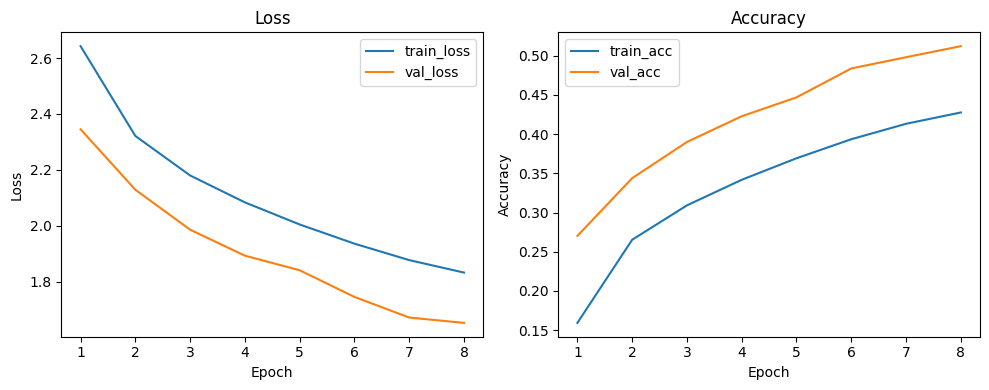

In [39]:
# Plot training/validation history for the best config
import matplotlib.pyplot as plt
hist = best.get('history')
if hist is None:
    print('No history available for best config')
else:
    epochs = list(range(1, len(hist['train_loss']) + 1))
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, hist['train_loss'], label='train_loss')
    plt.plot(epochs, hist['val_loss'], label='val_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(epochs, hist['train_acc'], label='train_acc')
    plt.plot(epochs, hist['val_acc'], label='val_acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()